In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [2]:
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print("📁 Path to dataset files:", path)

csv_file = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = pd.read_csv(csv_file)

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
📁 Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset

✅ Dataset Loaded!
📐 Shape: 1470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [5]:
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n🔢 Numerical Columns ({len(num_features)}):")
print(num_features)

print(f"\n🔤 Categorical Columns ({len(cat_features)}):")
print(cat_features)

print(f"\n🎯 Target: Attrition")
print(df['Attrition'].value_counts())


🔢 Numerical Columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

🔤 Categorical Columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

🎯 Target: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [6]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])
    df.fillna(df.median(numeric_only=True), inplace=True)
    print("✅ Missing values filled with median")

✅ No missing values found!


In [7]:
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print("✅ Duplicates removed!")
else:
    print("✅ No duplicates found!")


🔍 Duplicate rows: 0
✅ No duplicates found!


In [8]:
useless_cols = []
for col in df.columns:
    if df[col].nunique() == 1:
        useless_cols.append(col)

if useless_cols:
    df.drop(columns=useless_cols, inplace=True)
    print(f"\n✅ Dropped constant columns: {useless_cols}")
else:
    print(f"\n✅ No constant columns found!")

# ── 4.4 Drop EmployeeNumber (ID column)
if 'EmployeeNumber' in df.columns:
    df.drop(columns=['EmployeeNumber'], inplace=True)
    print("✅ 'EmployeeNumber' dropped (ID column)")


✅ Dropped constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
✅ 'EmployeeNumber' dropped (ID column)


In [9]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(lambda x: x.str.strip())
print("✅ Whitespace stripped from string columns")

✅ Whitespace stripped from string columns


In [12]:
print("\n🔍 Outlier Detection (IQR Method):")
num_cols_clean = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_info   = {}

for col in num_cols_clean:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    if outliers > 0:
        outlier_info[col] = outliers

print(f"  Columns with outliers: {len(outlier_info)}")
for col, count in outlier_info.items():
    print(f"  → {col}: {count} outliers")

# Cap outliers (Winsorization) instead of removing rows
for col in outlier_info.keys():
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR,
                            upper=Q3 + 1.5*IQR)
print("✅ Outliers capped using Winsorization (IQR method)")


🔍 Outlier Detection (IQR Method):
  Columns with outliers: 0
✅ Outliers capped using Winsorization (IQR method)


In [13]:
df.shape

(1470, 31)

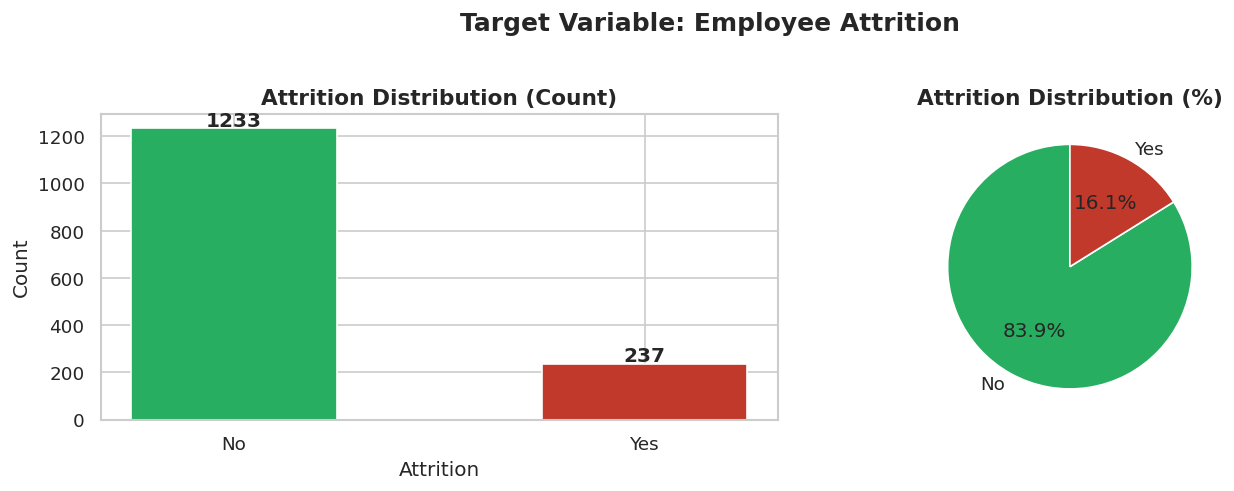

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

attr_counts = df['Attrition'].value_counts()

axes[0].bar(attr_counts.index, attr_counts.values,
            color=['#27ae60', '#c0392b'],
            edgecolor='white', width=0.5)
axes[0].set_title('Attrition Distribution (Count)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
for i, v in enumerate(attr_counts.values):
    axes[0].text(i, v + 10, str(v),
                 ha='center', fontweight='bold')

axes[1].pie(attr_counts.values,
            labels=attr_counts.index,
            autopct='%1.1f%%',
            colors=['#27ae60', '#c0392b'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Attrition Distribution (%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Employee Attrition',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('RF_01_attrition_distribution.png', bbox_inches='tight')
plt.show()

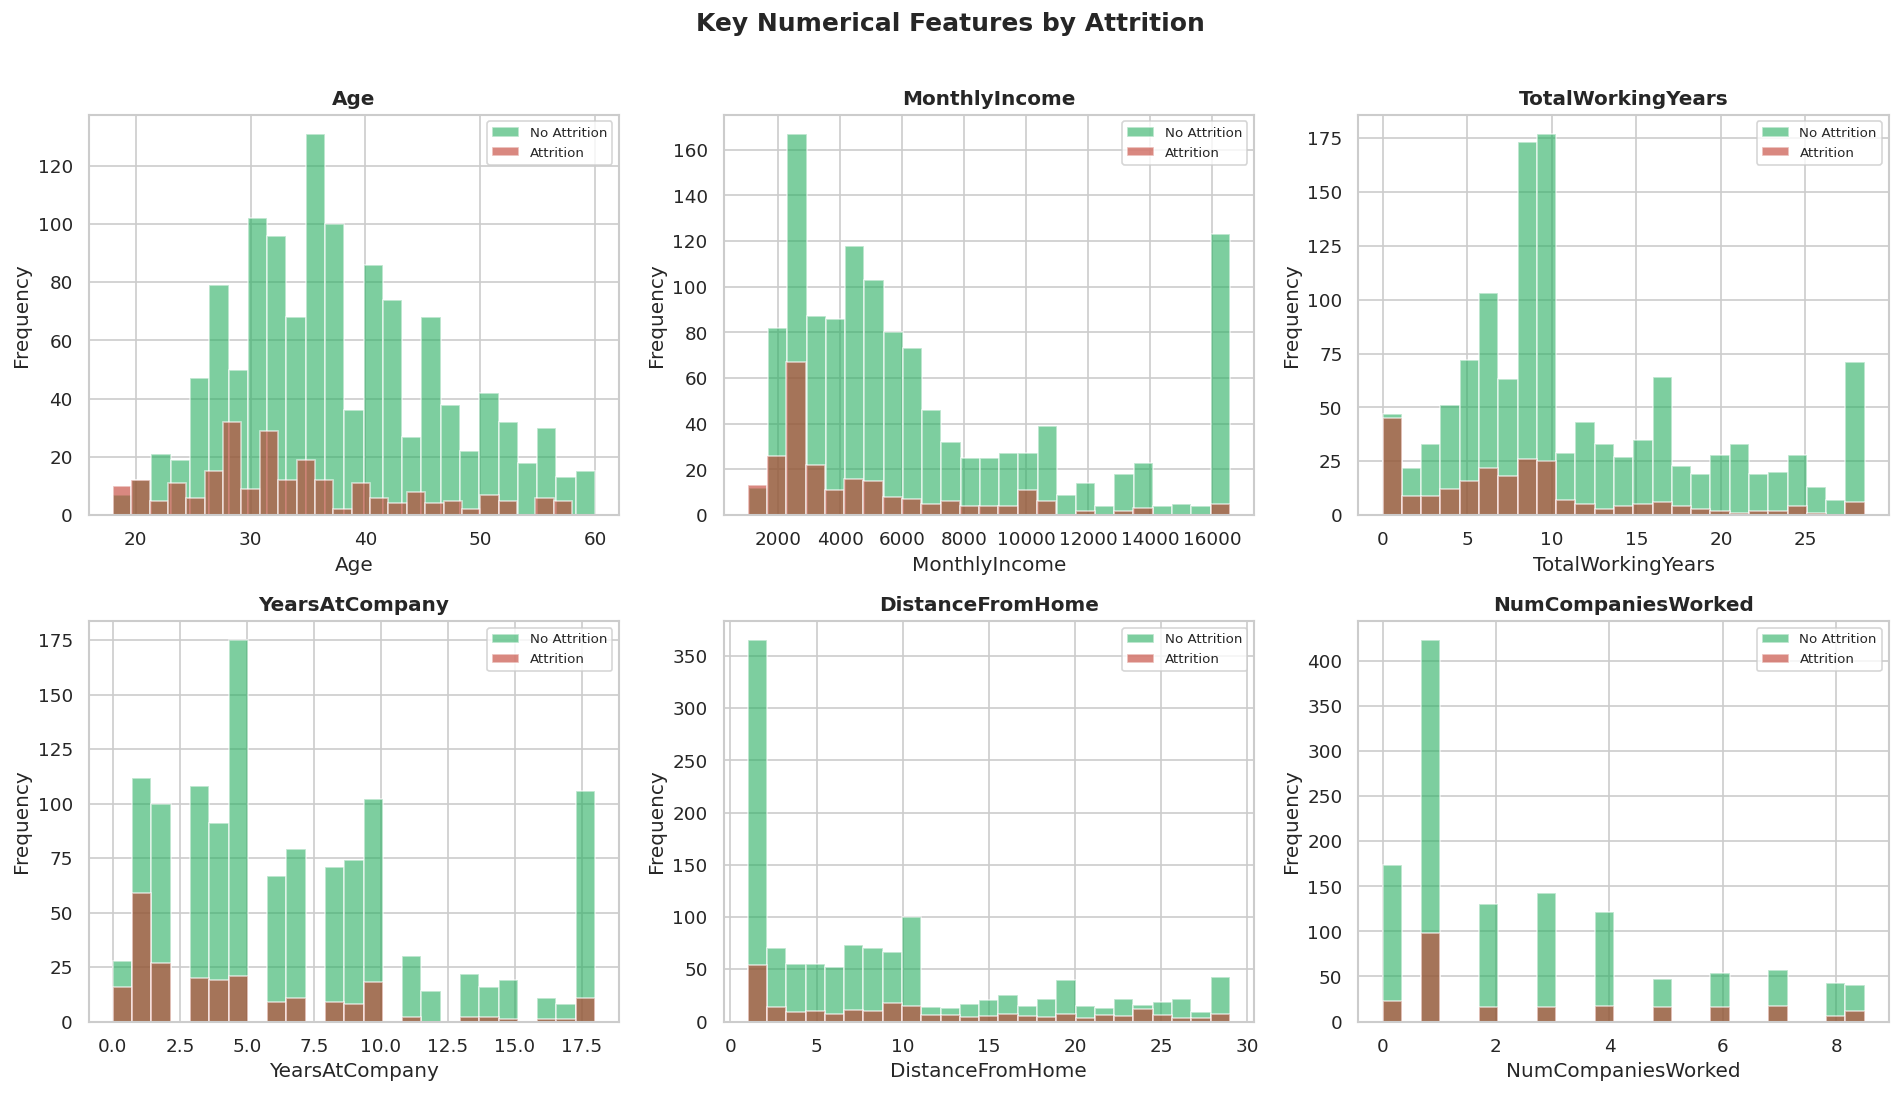

In [15]:
key_num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
                'YearsAtCompany', 'DistanceFromHome',
                'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    axes[i].hist(df[df['Attrition'] == 'No'][col],
                 bins=25, alpha=0.6, color='#27ae60',
                 label='No Attrition')
    axes[i].hist(df[df['Attrition'] == 'Yes'][col],
                 bins=25, alpha=0.6, color='#c0392b',
                 label='Attrition')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Key Numerical Features by Attrition',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('RF_02_numerical_distribution.png', bbox_inches='tight')
plt.show()

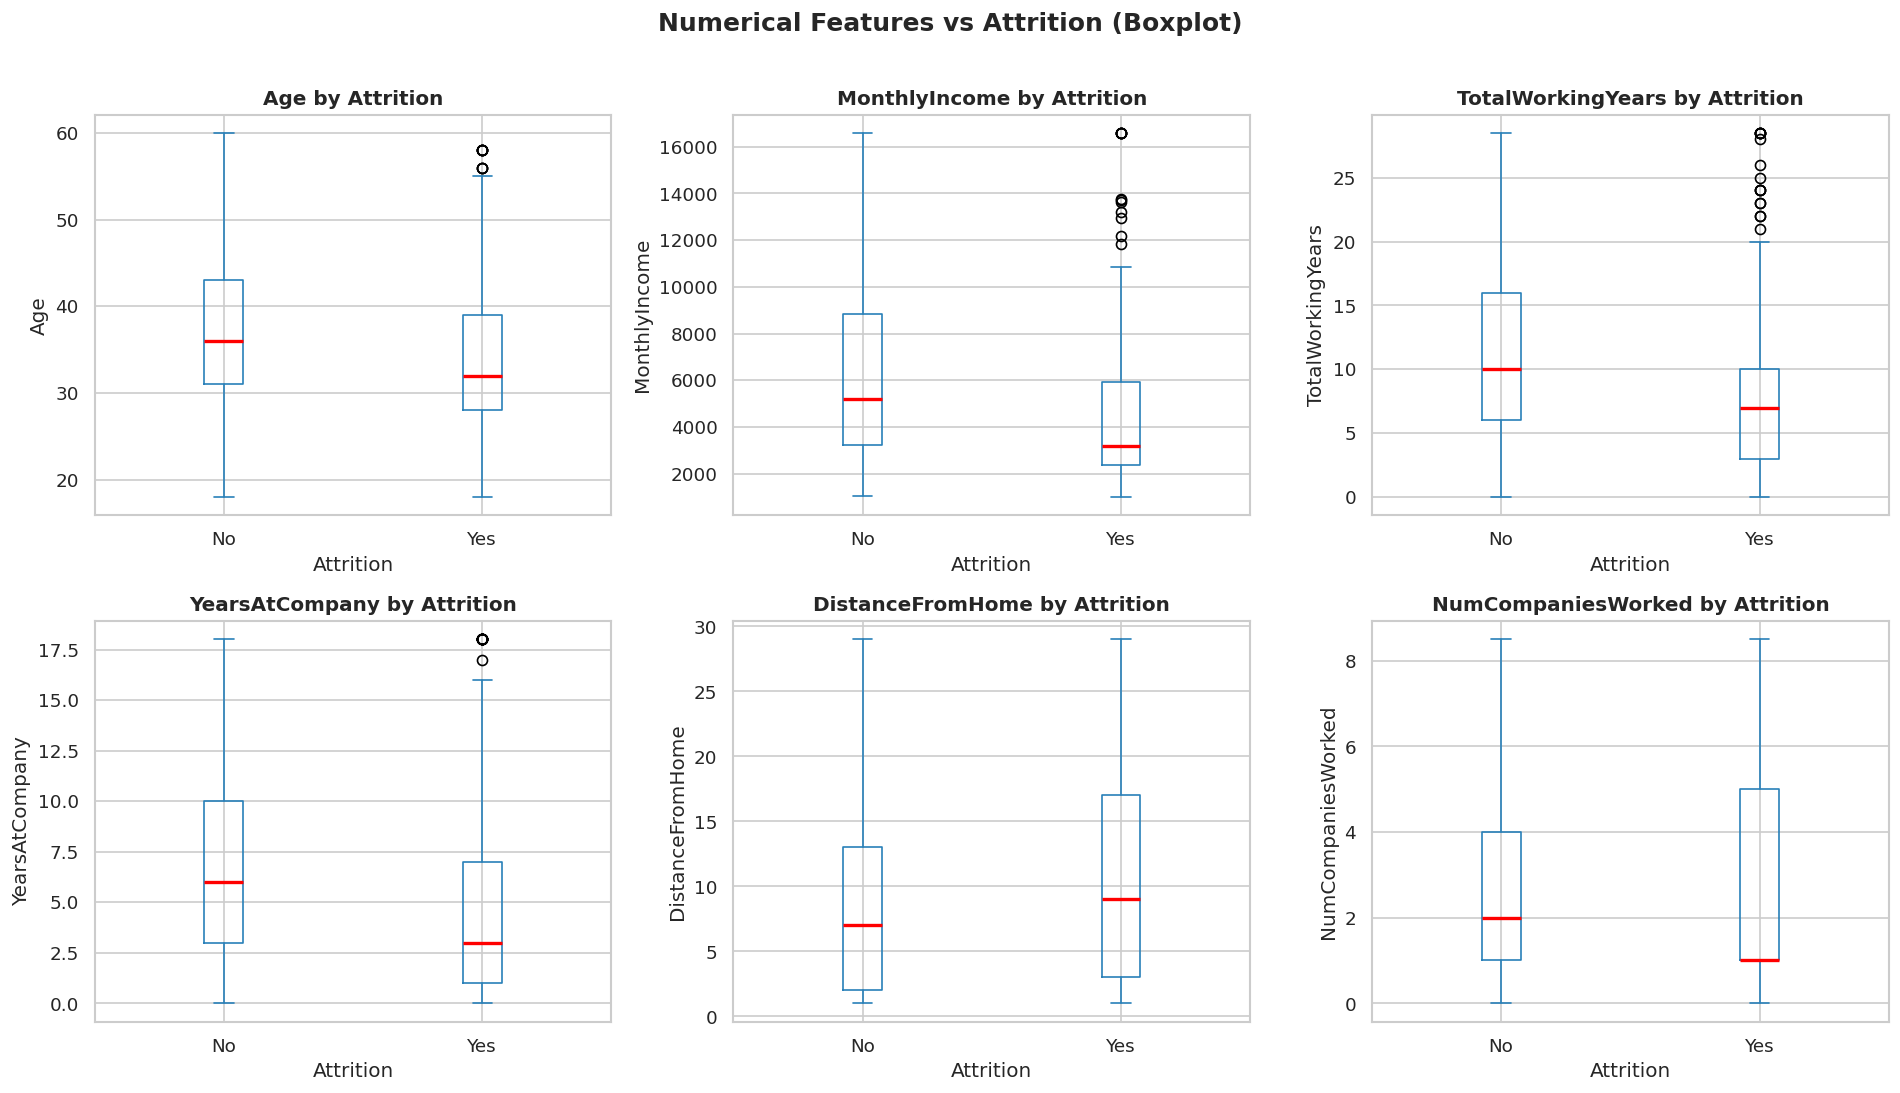

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    df.boxplot(column=col, by='Attrition', ax=axes[i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='#2980b9'),
               capprops=dict(color='#2980b9'))
    axes[i].set_title(f'{col} by Attrition', fontweight='bold')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel(col)

plt.suptitle('Numerical Features vs Attrition (Boxplot)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('RF_03_boxplots.png', bbox_inches='tight')
plt.show()

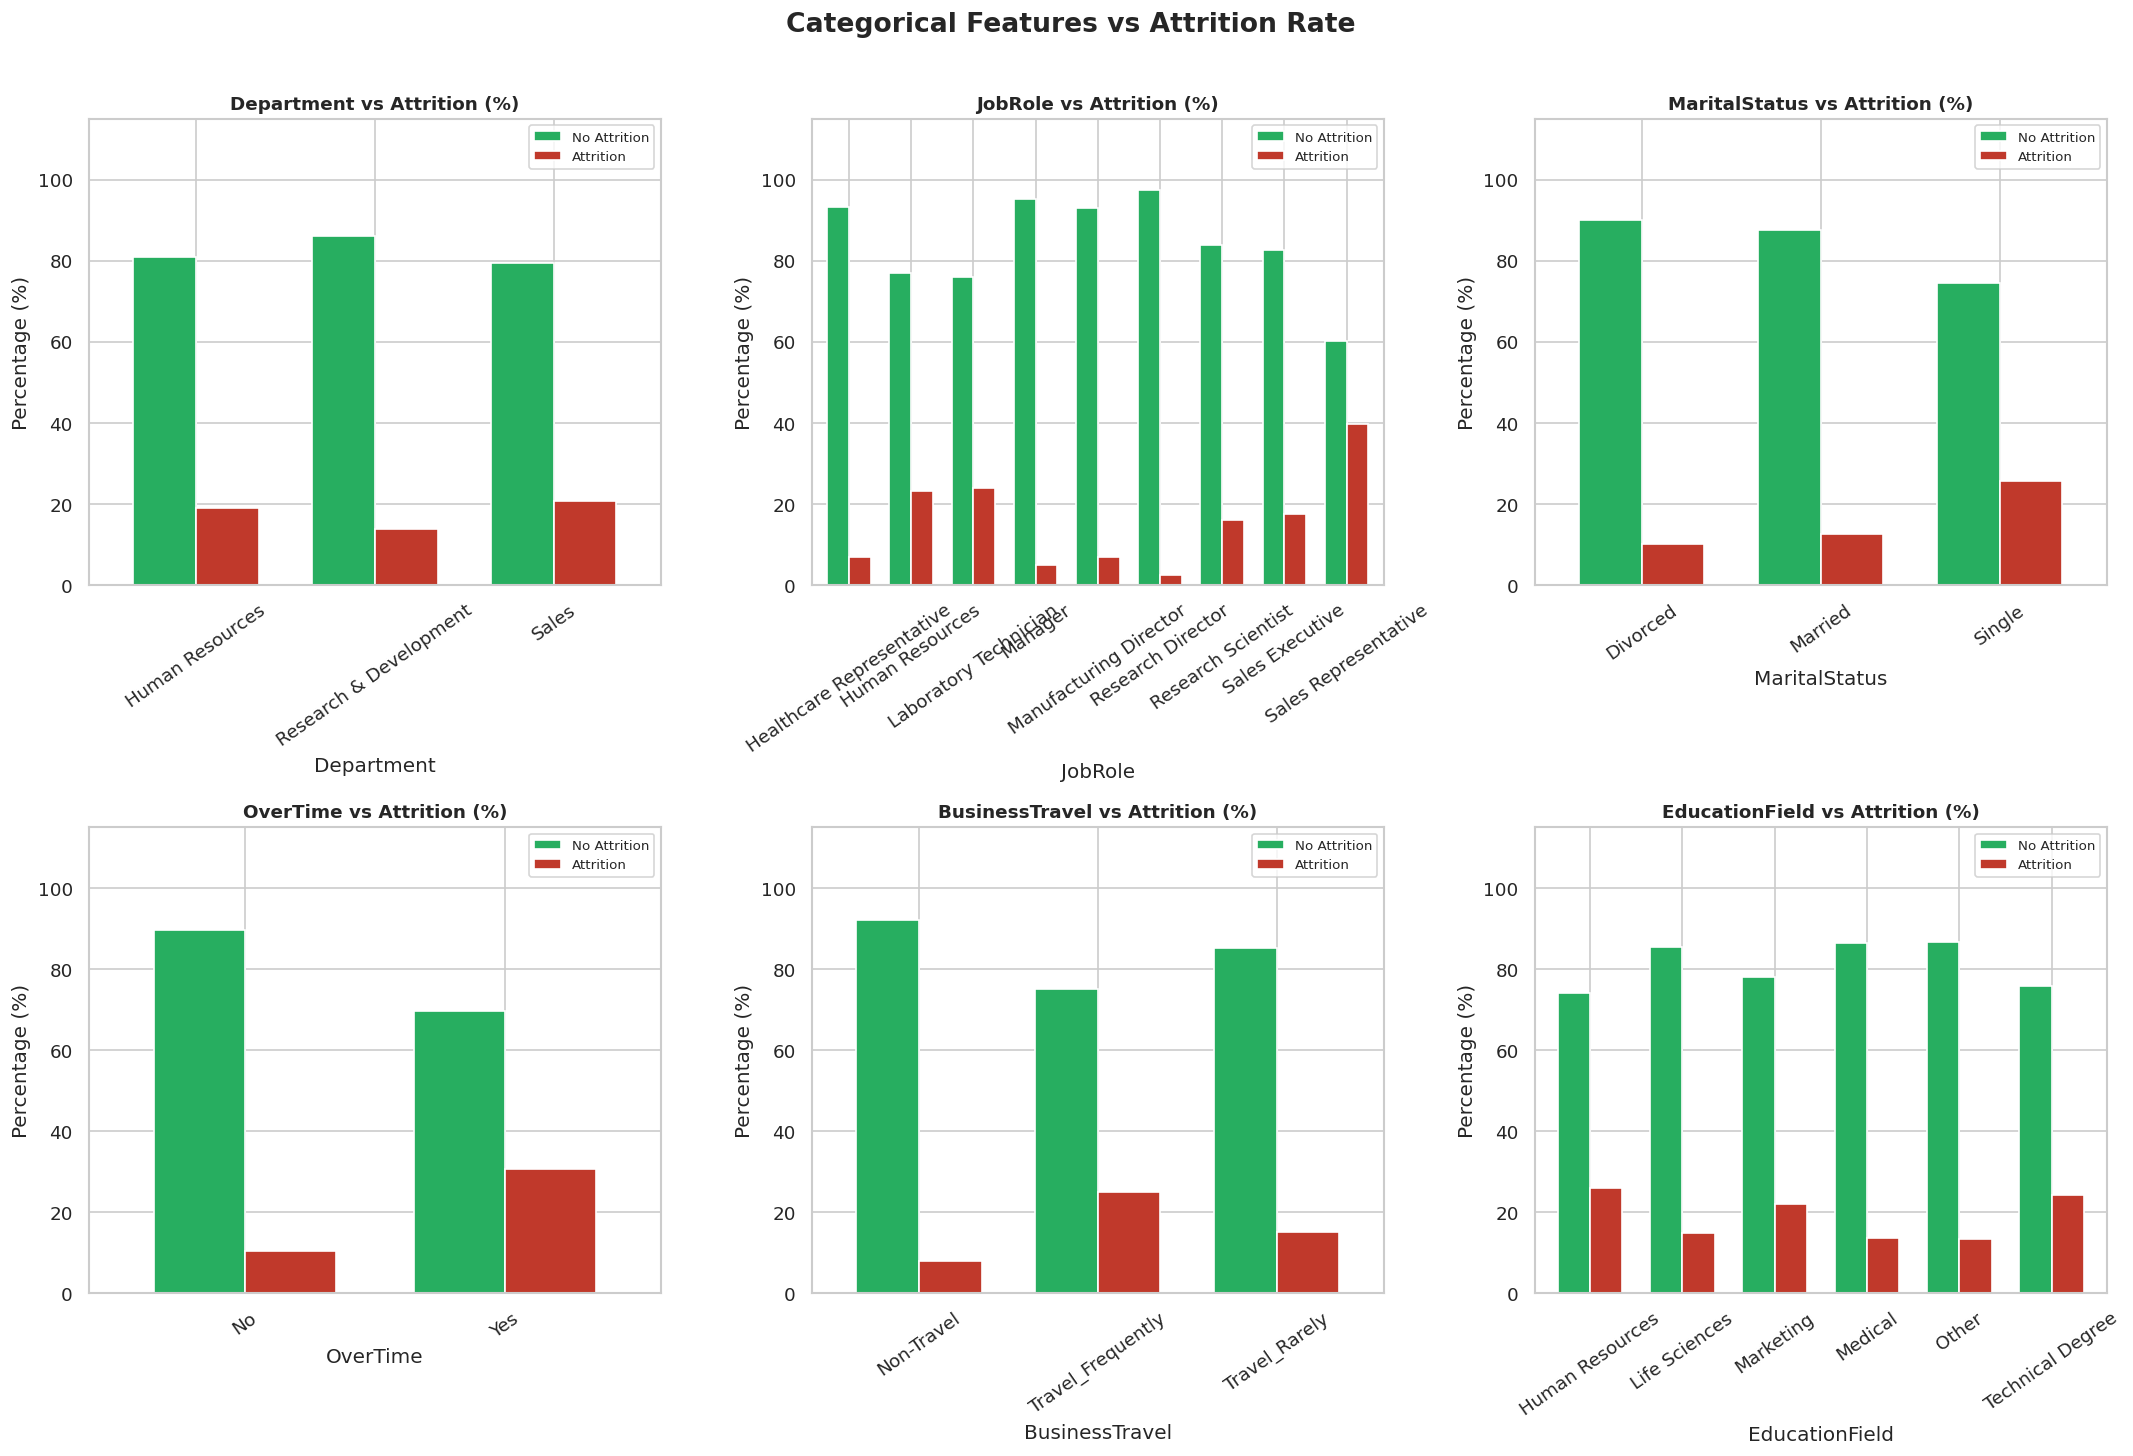

In [17]:
cat_cols_plot = ['Department', 'JobRole', 'MaritalStatus',
                 'OverTime', 'BusinessTravel', 'EducationField']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    ct = pd.crosstab(df[col], df['Attrition'],
                     normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i],
            color=['#27ae60', '#c0392b'],
            edgecolor='white', width=0.7)
    axes[i].set_title(f'{col} vs Attrition (%)',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(['No Attrition', 'Attrition'], fontsize=8)
    axes[i].set_ylim(0, 115)

plt.suptitle('Categorical Features vs Attrition Rate',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('RF_04_categorical_features.png', bbox_inches='tight')
plt.show()

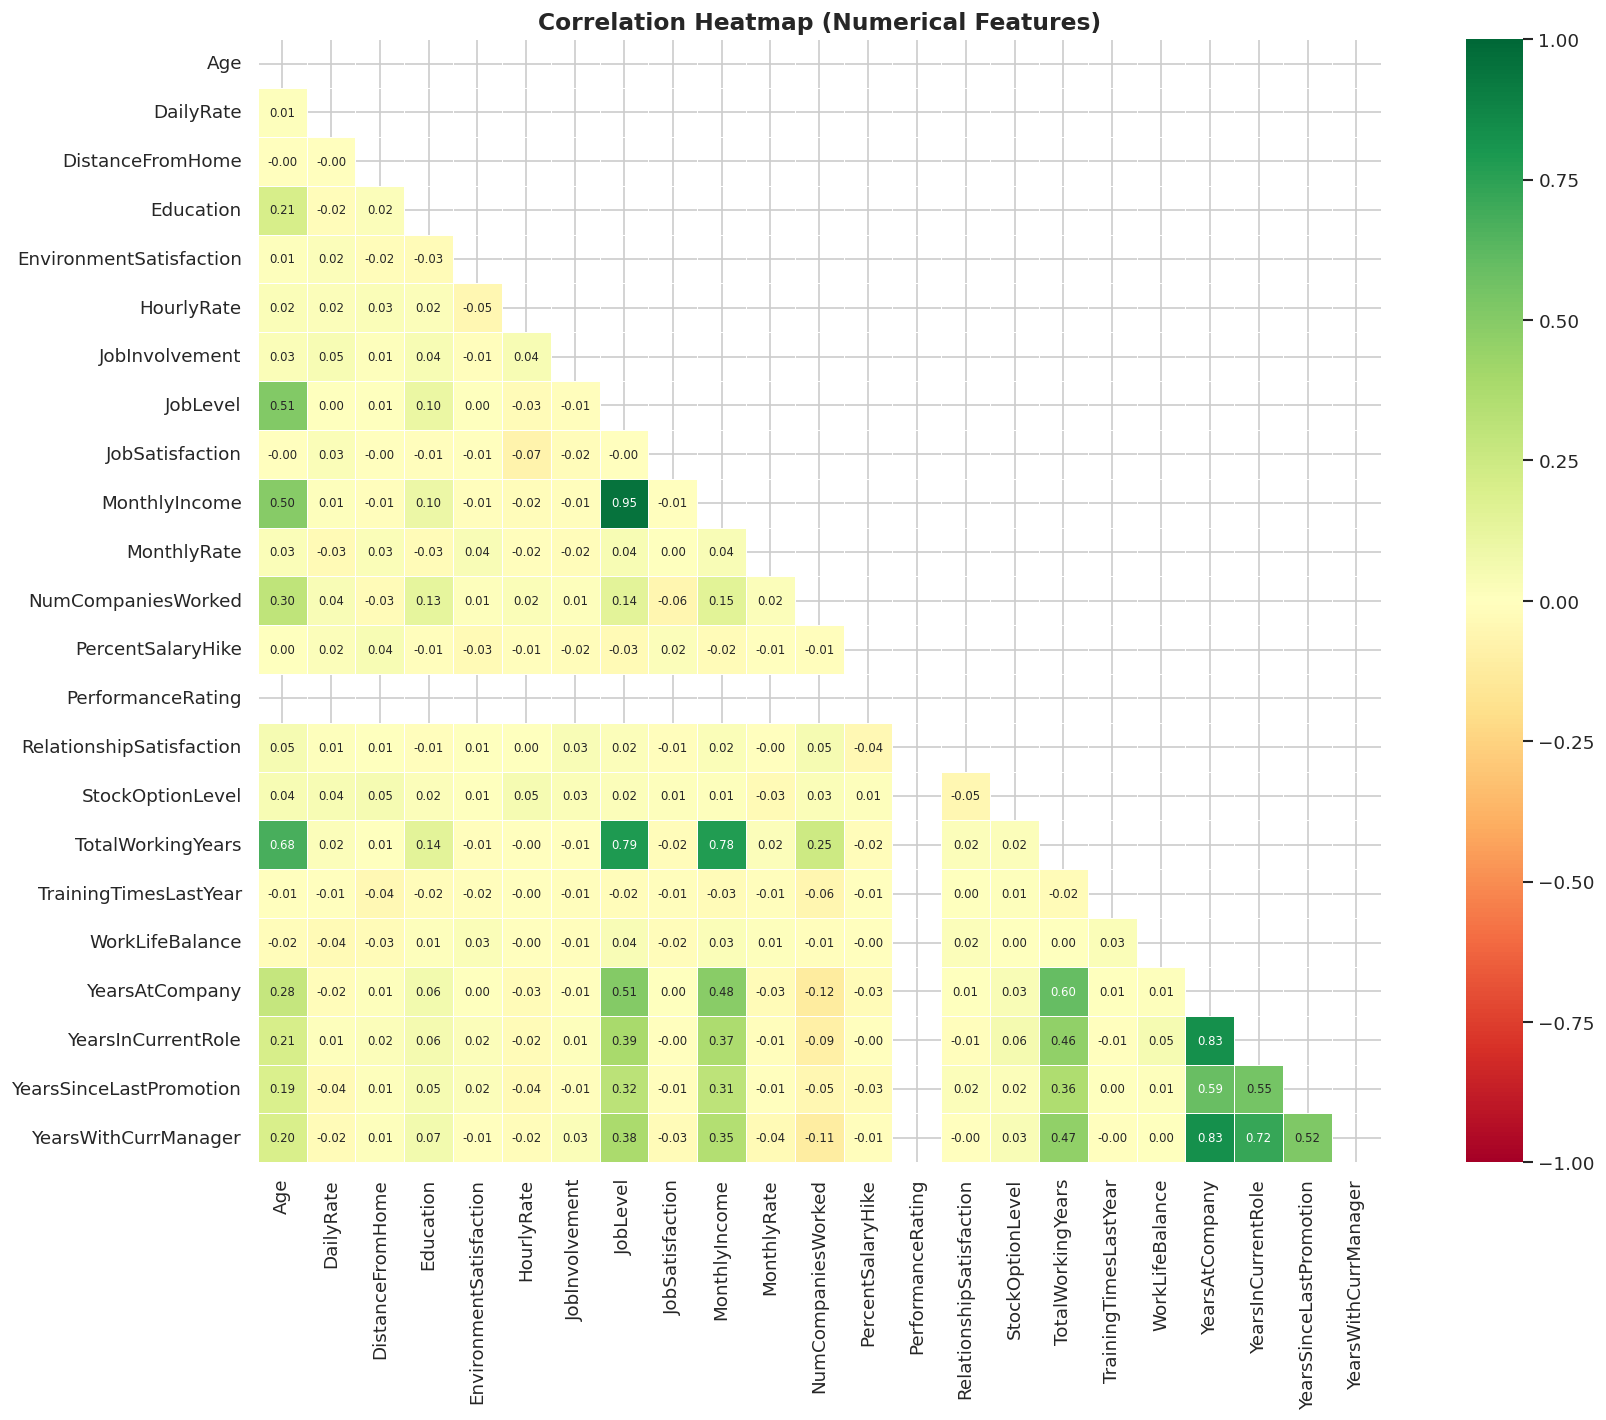

In [18]:
fig, ax = plt.subplots(figsize=(16, 12))

num_df = df.select_dtypes(include=[np.number]).copy()
corr   = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.3,
            ax=ax, annot_kws={'fontsize': 7},
            vmin=-1, vmax=1, center=0,
            square=True)
ax.set_title('Correlation Heatmap (Numerical Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('RF_05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

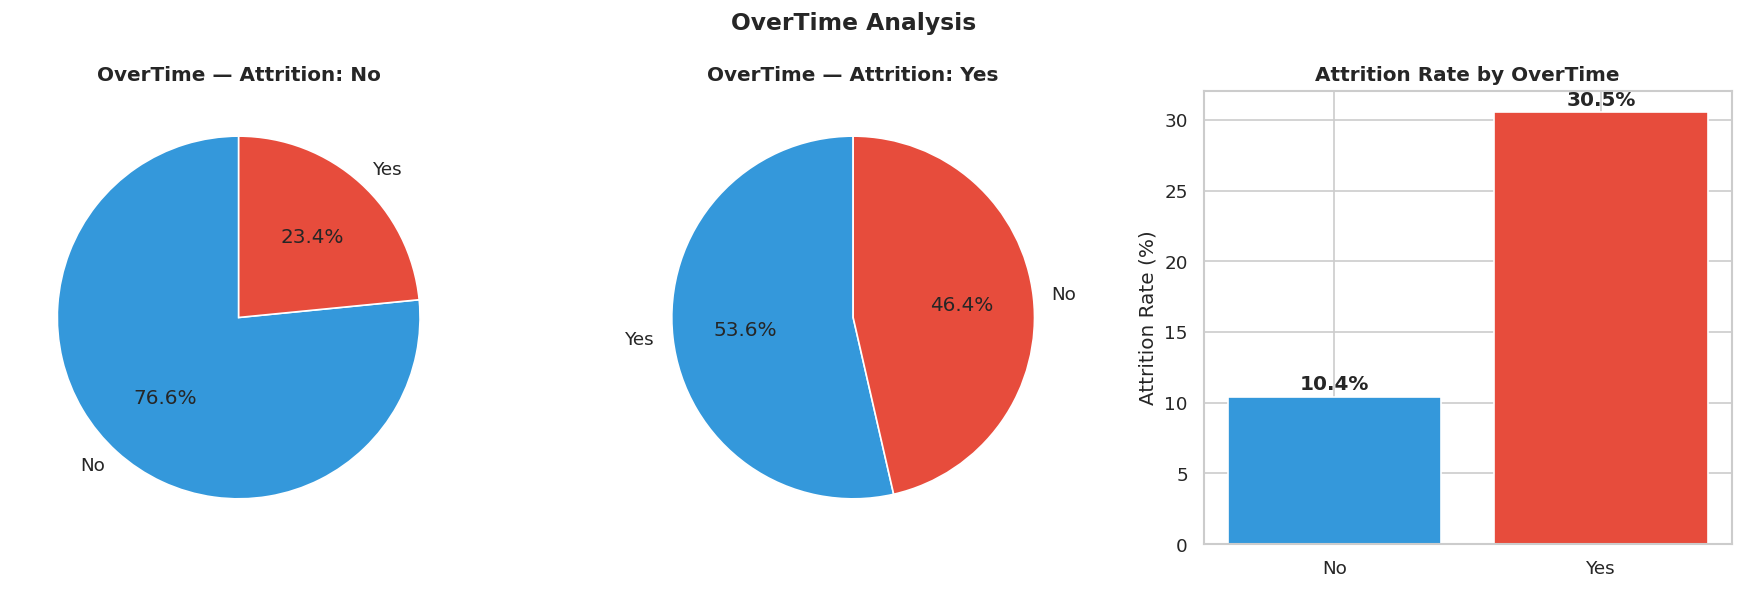

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overtime pie per group
for idx, (grp, color) in enumerate(
        zip(['No', 'Yes'], ['#27ae60', '#c0392b'])):
    ot_data = df[df['Attrition'] == grp]['OverTime'].value_counts()
    axes[idx].pie(ot_data.values,
                  labels=ot_data.index,
                  autopct='%1.1f%%',
                  colors=['#3498db', '#e74c3c'],
                  startangle=90,
                  wedgeprops={'edgecolor': 'white'})
    axes[idx].set_title(f'OverTime — Attrition: {grp}',
                        fontweight='bold')

# Attrition rate by Overtime
ot_rate = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
ot_rate.columns = ['OverTime', 'AttritionRate']
axes[2].bar(ot_rate['OverTime'], ot_rate['AttritionRate'],
            color=['#3498db', '#e74c3c'], edgecolor='white')
axes[2].set_title('Attrition Rate by OverTime',
                  fontweight='bold')
axes[2].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(ot_rate['AttritionRate']):
    axes[2].text(i, v + 0.5, f'{v:.1f}%',
                 ha='center', fontweight='bold')

plt.suptitle('OverTime Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('RF_06_overtime_analysis.png', bbox_inches='tight')
plt.show()

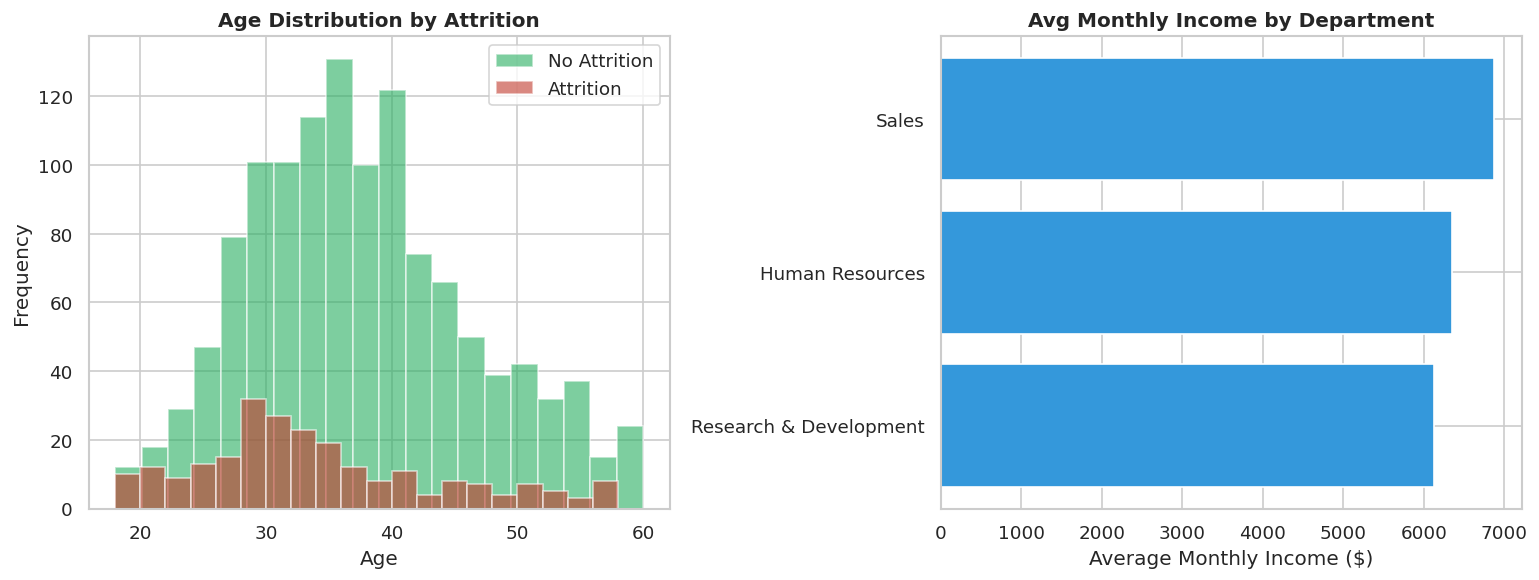

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age by Attrition
for grp, color in zip(['No', 'Yes'], ['#27ae60', '#c0392b']):
    axes[0].hist(df[df['Attrition'] == grp]['Age'],
                 bins=20, alpha=0.6, color=color, label=f'{grp}')
axes[0].set_title('Age Distribution by Attrition',
                  fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend(['No Attrition', 'Attrition'])

# MonthlyIncome by Department
dept_income = df.groupby('Department')['MonthlyIncome'].mean().sort_values()
axes[1].barh(dept_income.index, dept_income.values,
             color='#3498db', edgecolor='white')
axes[1].set_title('Avg Monthly Income by Department',
                  fontweight='bold')
axes[1].set_xlabel('Average Monthly Income ($)')

plt.tight_layout()
plt.savefig('RF_07_age_income.png', bbox_inches='tight')
plt.show()

In [21]:
df_model = df.copy()

# ── 6.1 Encode Target
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})
print("✅ Target encoded → Yes:1 / No:0")

# ── 6.2 Binary Encoding
binary_map = {'Yes': 1, 'No': 0,
              'Male': 1, 'Female': 0}

binary_cols = ['Gender', 'OverTime']
for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(binary_map)
print(f"✅ Binary encoded: {binary_cols}")

# ── 6.3 Ordinal Encoding
ordinal_maps = {
    'BusinessTravel': {
        'Non-Travel': 0,
        'Travel_Rarely': 1,
        'Travel_Frequently': 2
    },
    'Education': {1: 1, 2: 2, 3: 3, 4: 4, 5: 5},
    'EnvironmentSatisfaction' : {1:1, 2:2, 3:3, 4:4},
    'JobInvolvement'          : {1:1, 2:2, 3:3, 4:4},
    'JobSatisfaction'         : {1:1, 2:2, 3:3, 4:4},
    'PerformanceRating'       : {1:1, 2:2, 3:3, 4:4},
    'RelationshipSatisfaction': {1:1, 2:2, 3:3, 4:4},
    'WorkLifeBalance'         : {1:1, 2:2, 3:3, 4:4},
}

for col, mapping in ordinal_maps.items():
    if col in df_model.columns:
        df_model[col] = df_model[col].map(mapping)
print(f"✅ Ordinal encoding applied to {len(ordinal_maps)} columns")

# ── 6.4 One-Hot Encoding for remaining categoricals
remaining_cat = df_model.select_dtypes(include='object').columns.tolist()
if remaining_cat:
    df_model = pd.get_dummies(df_model,
                               columns=remaining_cat,
                               drop_first=True)
    print(f"✅ One-Hot Encoding applied to: {remaining_cat}")

# ── 6.5 Handle remaining nulls
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

print(f"\n📐 Final Shape after encoding: {df_model.shape}")
df_model.head(3)

✅ Target encoded → Yes:1 / No:0
✅ Binary encoded: ['Gender', 'OverTime']
✅ Ordinal encoding applied to 8 columns
✅ One-Hot Encoding applied to: ['Department', 'EducationField', 'JobRole', 'MaritalStatus']

📐 Final Shape after encoding: (1470, 44)


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,1,2,2,0,94,3,...,False,False,False,False,False,False,True,False,False,True
1,49,0,2,279,8,1,3,1,61,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1,1373,2,2,4,1,92,2,...,False,True,False,False,False,False,False,False,False,True


In [22]:
df_model['years_per_company'] = (
    df_model['TotalWorkingYears'] /
    (df_model['NumCompaniesWorked'] + 1)
)
print("✅ 'years_per_company' created")

# Income per age ratio
df_model['income_per_age'] = (
    df_model['MonthlyIncome'] /
    (df_model['Age'] + 1)
)
print("✅ 'income_per_age' created")

# Satisfaction score (mean of all satisfaction cols)
sat_cols = ['EnvironmentSatisfaction', 'JobInvolvement',
            'JobSatisfaction', 'RelationshipSatisfaction',
            'WorkLifeBalance']
available_sat = [c for c in sat_cols if c in df_model.columns]
df_model['avg_satisfaction'] = df_model[available_sat].mean(axis=1)
print("✅ 'avg_satisfaction' created")

# Loyalty score
df_model['loyalty_score'] = (
    df_model['YearsAtCompany'] /
    (df_model['TotalWorkingYears'] + 1)
)
print("✅ 'loyalty_score' created")

✅ 'years_per_company' created
✅ 'income_per_age' created
✅ 'avg_satisfaction' created
✅ 'loyalty_score' created


In [23]:
df_model.shape

(1470, 48)

In [24]:
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

print(f"🎯 Target distribution:\n{y.value_counts()}")
print(f"\n⚠️  Class imbalance ratio: "
      f"{y.value_counts()[0]/y.value_counts()[1]:.1f}:1")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# NOTE: Random Forest does NOT need scaling
# but we save scaler for reference
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Training set : {X_train.shape}")
print(f"✅ Test set     : {X_test.shape}")
print(f"✅ Features     : {X_train.shape[1]}")

🎯 Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

⚠️  Class imbalance ratio: 5.2:1

✅ Training set : (1176, 47)
✅ Test set     : (294, 47)
✅ Features     : 47


In [25]:
rf_baseline = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    class_weight = 'balanced',
    n_jobs       = -1
)
rf_baseline.fit(X_train, y_train)

y_pred_base      = rf_baseline.predict(X_test)
y_pred_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, y_pred_prob_base)

print(f"  Accuracy (Baseline) : {acc_base*100:.2f}%")
print(f"  ROC-AUC  (Baseline) : {roc_base:.4f}")
print(f"  n_estimators        : 100")

  Accuracy (Baseline) : 84.69%
  ROC-AUC  (Baseline) : 0.7534
  n_estimators        : 100


In [26]:
param_dist = {
    'n_estimators'     : [50, 100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf' : [1, 2, 4, 6],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap'        : [True, False]
}

rand_search = RandomizedSearchCV(
    estimator  = RandomForestClassifier(
                     class_weight='balanced',
                     random_state=42,
                     n_jobs=-1),
    param_distributions = param_dist,
    n_iter     = 30,
    cv         = StratifiedKFold(5),
    scoring    = 'roc_auc',
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)
rand_search.fit(X_train, y_train)

print(f"\n✅ Best Params (Random)  : {rand_search.best_params_}")
print(f"✅ Best CV ROC-AUC       : {rand_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Params (Random)  : {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
✅ Best CV ROC-AUC       : 0.8010


In [27]:
best_p = rand_search.best_params_

param_grid = {
    'n_estimators': [
        max(50, best_p['n_estimators'] - 50),
        best_p['n_estimators'],
        best_p['n_estimators'] + 50
    ],
    'max_depth': [
        best_p['max_depth'],
        (best_p['max_depth'] + 5)
        if best_p['max_depth'] is not None else None
    ],
    'min_samples_split': [
        max(2, best_p['min_samples_split'] - 2),
        best_p['min_samples_split'],
        best_p['min_samples_split'] + 2
    ],
    'min_samples_leaf': [
        max(1, best_p['min_samples_leaf'] - 1),
        best_p['min_samples_leaf']
    ],
    'max_features' : [best_p['max_features']],
    'bootstrap'    : [best_p['bootstrap']]
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(
                     class_weight='balanced',
                     random_state=42,
                     n_jobs=-1),
    param_grid = param_grid,
    cv         = StratifiedKFold(5),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train, y_train)

print(f"\n✅ Best Params (Grid)    : {grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC       : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Params (Grid)    : {'bootstrap': True, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
✅ Best CV ROC-AUC       : 0.8010


In [28]:
rf_best = grid_search.best_estimator_
rf_best.fit(X_train, y_train)

y_pred      = rf_best.predict(X_test)
y_pred_prob = rf_best.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_pred_prob)
cv   = cross_val_score(rf_best, X_train, y_train,
                       cv=StratifiedKFold(5),
                       scoring='roc_auc')

print(f"\n{'Metric':<30} {'Score':>10}")
print("-" * 42)
print(f"{'Accuracy':<30} {acc*100:>9.2f}%")
print(f"{'ROC-AUC':<30} {roc:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<30} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<30} {cv.std():>10.4f}")
print(f"{'n_estimators':<30} {rf_best.n_estimators:>10}")
print(f"{'max_depth':<30} {str(rf_best.max_depth):>10}")

print(f"\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred,
                            target_names=['No Attrition',
                                          'Attrition']))


Metric                              Score
------------------------------------------
Accuracy                           82.99%
ROC-AUC                            0.7575
CV ROC-AUC (mean)                  0.8010
CV ROC-AUC (std)                   0.0553
n_estimators                           50
max_depth                            None

📋 Classification Report:

              precision    recall  f1-score   support

No Attrition       0.88      0.93      0.90       247
   Attrition       0.45      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.62      0.64       294
weighted avg       0.81      0.83      0.82       294



In [29]:
comparison = pd.DataFrame({
    'Model'   : ['Baseline RF', 'Tuned RF'],
    'Accuracy': [f"{acc_base*100:.2f}%", f"{acc*100:.2f}%"],
    'ROC-AUC' : [f"{roc_base:.4f}", f"{roc:.4f}"],
    'n_estimators': [100, rf_best.n_estimators],
    'max_depth'   : [None, rf_best.max_depth]
})
print(comparison.to_string(index=False))

      Model Accuracy ROC-AUC  n_estimators max_depth
Baseline RF   84.69%  0.7534           100      None
   Tuned RF   82.99%  0.7575            50      None


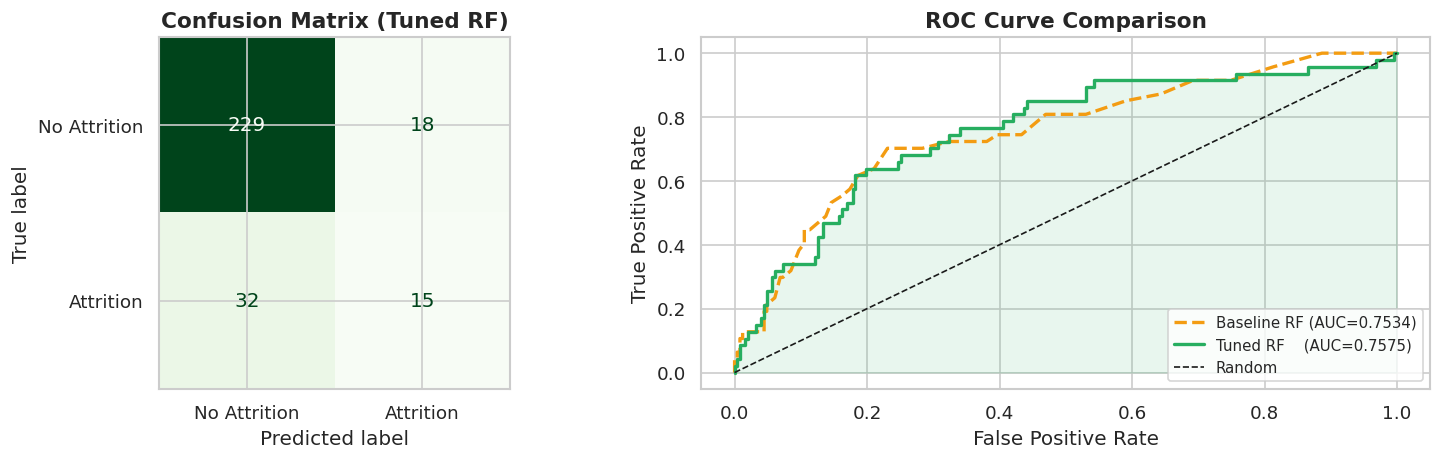

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
           confusion_matrix=cm,
           display_labels=['No Attrition', 'Attrition'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix (Tuned RF)',
                  fontsize=13, fontweight='bold')

# ROC Curve — Baseline vs Tuned
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_prob_base)
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_prob)

axes[1].plot(fpr_base, tpr_base, color='#f39c12',
             lw=2, linestyle='--',
             label=f'Baseline RF (AUC={roc_base:.4f})')
axes[1].plot(fpr_best, tpr_best, color='#27ae60',
             lw=2,
             label=f'Tuned RF    (AUC={roc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[1].fill_between(fpr_best, tpr_best,
                     alpha=0.1, color='#27ae60')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('RF_08_confusion_roc.png', bbox_inches='tight')
plt.show()

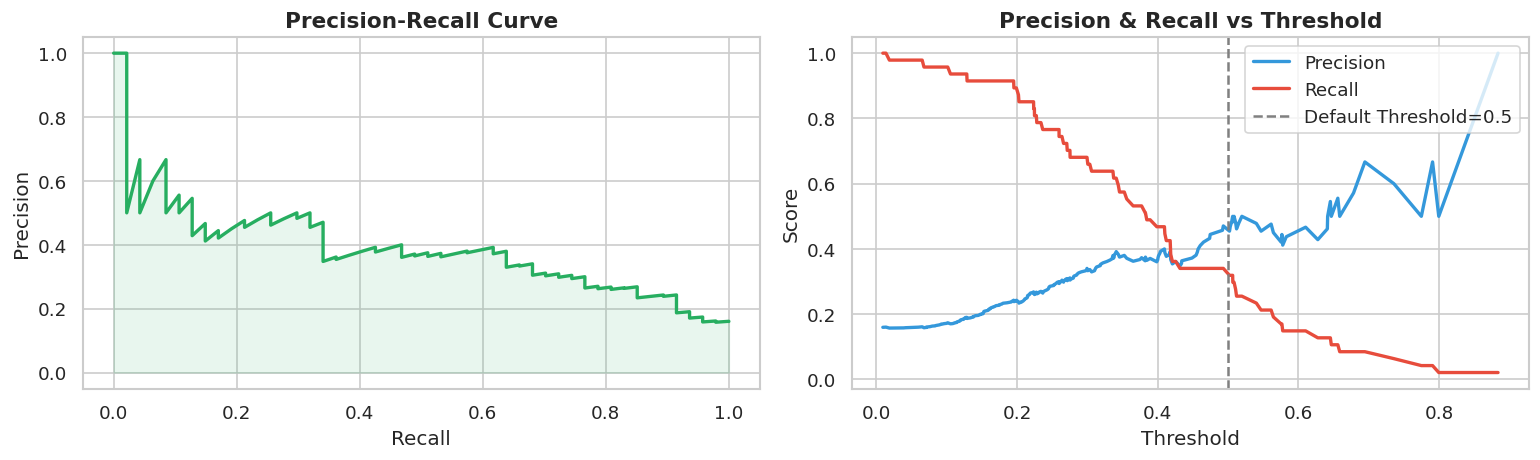

In [31]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PR Curve
axes[0].plot(recall, precision, color='#27ae60', lw=2)
axes[0].fill_between(recall, precision,
                     alpha=0.1, color='#27ae60')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve',
                  fontsize=13, fontweight='bold')

# Threshold Analysis
axes[1].plot(thresholds,
             precision[:-1], color='#3498db', lw=2,
             label='Precision')
axes[1].plot(thresholds,
             recall[:-1], color='#e74c3c', lw=2,
             label='Recall')
axes[1].axvline(x=0.5, color='gray',
                linestyle='--', label='Default Threshold=0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Threshold',
                  fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('RF_09_precision_recall.png', bbox_inches='tight')
plt.show()

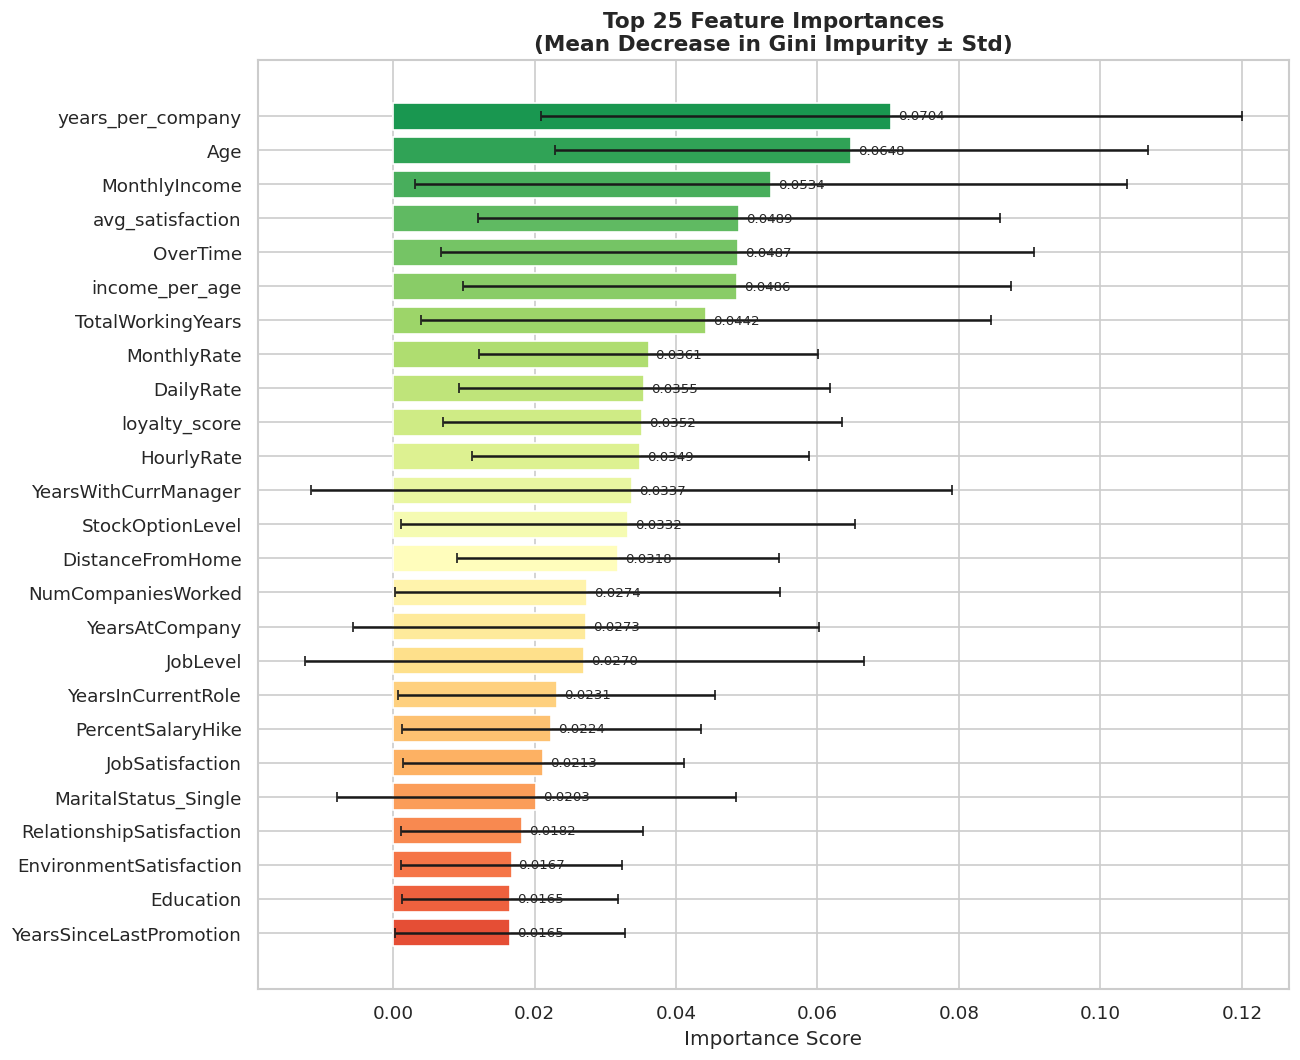

In [32]:
feature_names = X.columns.tolist()
importances   = rf_best.feature_importances_
std_imp       = np.std(
    [tree.feature_importances_
     for tree in rf_best.estimators_], axis=0)

feat_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances,
    'Std'       : std_imp
}).sort_values('Importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 9))
colors = plt.cm.RdYlGn(
    np.linspace(0.15, 0.9, len(feat_imp)))[::-1]

bars = ax.barh(feat_imp['Feature'],
               feat_imp['Importance'],
               xerr=feat_imp['Std'],
               color=colors, edgecolor='white',
               capsize=3)

ax.set_title('Top 25 Feature Importances\n'
             '(Mean Decrease in Gini Impurity ± Std)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()

for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('RF_10_feature_importance_gini.png',
            bbox_inches='tight')
plt.show()

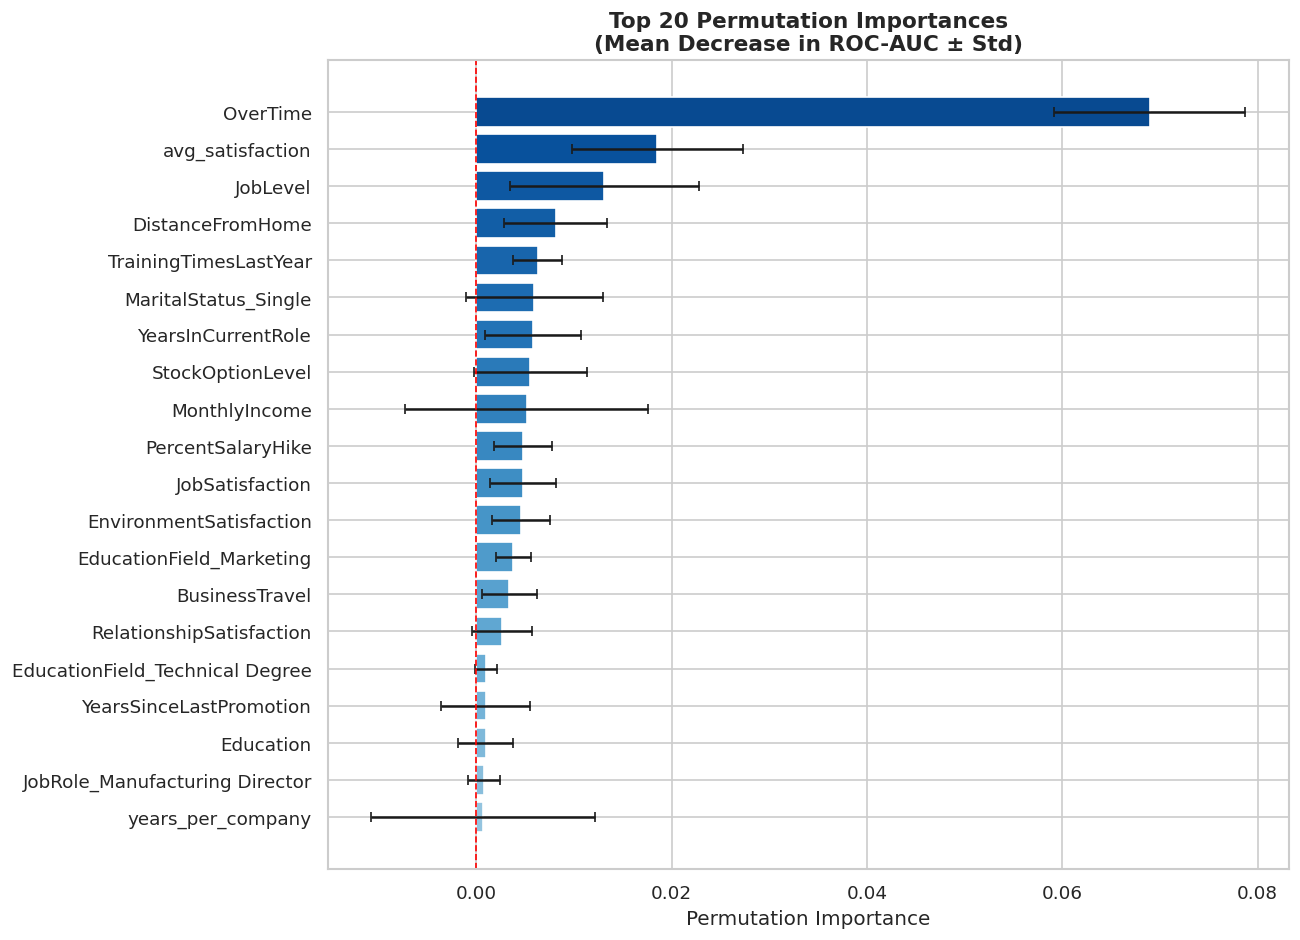

In [33]:
perm_imp = permutation_importance(
    rf_best, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 8))
colors  = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(perm_df)))[::-1]

ax.barh(perm_df['Feature'], perm_df['Importance'],
        xerr=perm_df['Std'],
        color=colors, edgecolor='white', capsize=3)
ax.set_title('Top 20 Permutation Importances\n'
             '(Mean Decrease in ROC-AUC ± Std)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Permutation Importance')
ax.axvline(x=0, color='red',
           linestyle='--', linewidth=1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('RF_11_permutation_importance.png',
            bbox_inches='tight')
plt.show()

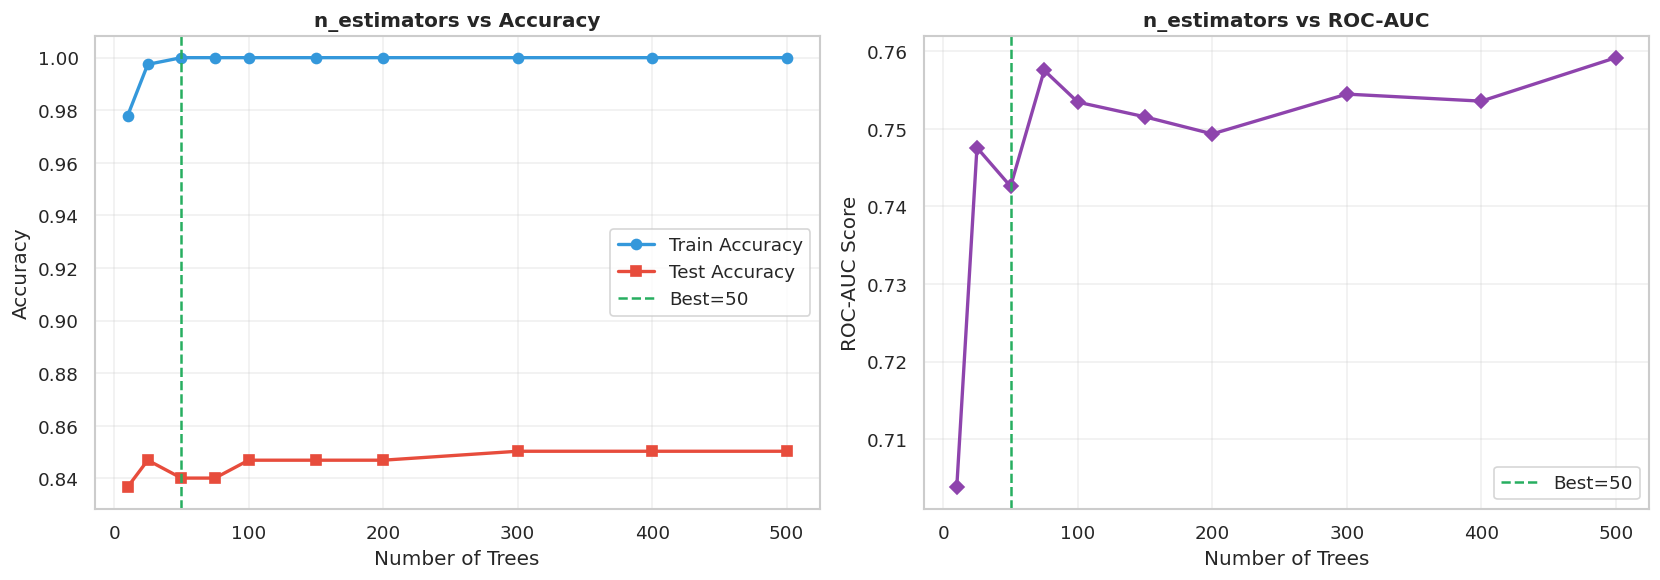

In [34]:
estimator_range = [10, 25, 50, 75, 100,
                   150, 200, 300, 400, 500]
train_scores    = []
test_scores_acc = []
test_scores_roc = []

for n in estimator_range:
    rf_temp = RandomForestClassifier(
        n_estimators = n,
        max_depth    = rf_best.max_depth,
        class_weight = 'balanced',
        random_state = 42,
        n_jobs       = -1
    )
    rf_temp.fit(X_train, y_train)
    train_scores.append(
        accuracy_score(y_train, rf_temp.predict(X_train)))
    test_scores_acc.append(
        accuracy_score(y_test, rf_temp.predict(X_test)))
    test_scores_roc.append(
        roc_auc_score(y_test,
                      rf_temp.predict_proba(X_test)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(estimator_range, train_scores,
             'o-', color='#3498db', lw=2,
             label='Train Accuracy')
axes[0].plot(estimator_range, test_scores_acc,
             's-', color='#e74c3c', lw=2,
             label='Test Accuracy')
axes[0].axvline(x=rf_best.n_estimators,
                color='#27ae60', linestyle='--',
                label=f'Best={rf_best.n_estimators}')
axes[0].set_title('n_estimators vs Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(estimator_range, test_scores_roc,
             'D-', color='#8e44ad', lw=2)
axes[1].axvline(x=rf_best.n_estimators,
                color='#27ae60', linestyle='--',
                label=f'Best={rf_best.n_estimators}')
axes[1].set_title('n_estimators vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('RF_12_estimators_analysis.png',
            bbox_inches='tight')
plt.show()

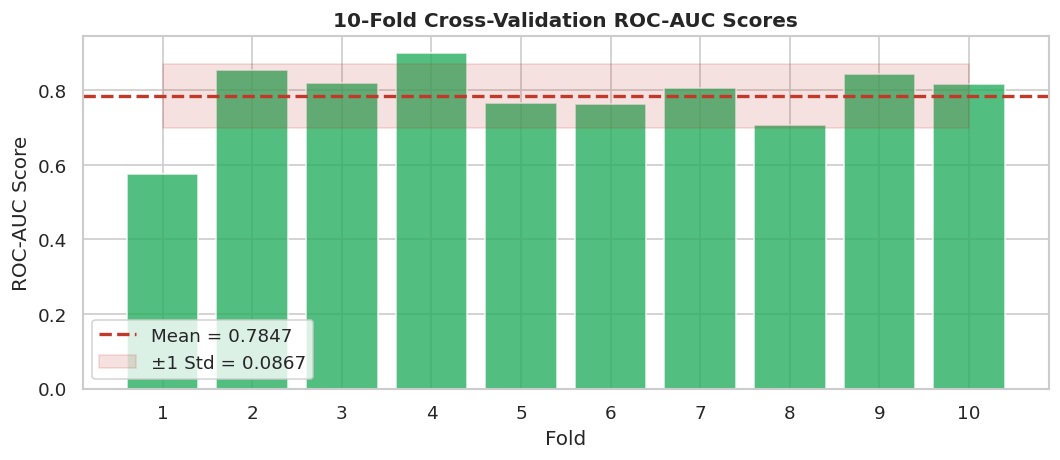

In [35]:
cv_scores = cross_val_score(rf_best, X_train, y_train,
                            cv=StratifiedKFold(10),
                            scoring='roc_auc')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), cv_scores,
       color='#27ae60', edgecolor='white', alpha=0.8)
ax.axhline(y=cv_scores.mean(), color='#c0392b',
           linestyle='--', lw=2,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.fill_between(
    range(1, 11),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.15, color='#c0392b',
    label=f'±1 Std = {cv_scores.std():.4f}')
ax.set_title('10-Fold Cross-Validation ROC-AUC Scores',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC Score')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('RF_13_cv_scores.png', bbox_inches='tight')
plt.show()

In [36]:
rf_oob = RandomForestClassifier(
    n_estimators = rf_best.n_estimators,
    max_depth    = rf_best.max_depth,
    class_weight = 'balanced',
    oob_score    = True,
    random_state = 42,
    n_jobs       = -1
)
rf_oob.fit(X_train, y_train)

print(f"✅ OOB Score (Accuracy) : {rf_oob.oob_score_:.4f}")
print(f"✅ Test Accuracy        : {acc:.4f}")
print(f"✅ Difference           : "
      f"{abs(rf_oob.oob_score_ - acc):.4f}")

✅ OOB Score (Accuracy) : 0.8571
✅ Test Accuracy        : 0.8299
✅ Difference           : 0.0272


In [37]:
# Save tuned RF model
joblib.dump(rf_best, 'random_forest_attrition_model.pkl')
print("✅ Model saved      → random_forest_attrition_model.pkl")

# Save scaler
joblib.dump(scaler, 'RF_scaler.pkl')
print("✅ Scaler saved     → RF_scaler.pkl")

# Save feature names
feature_df = pd.DataFrame({'features': feature_names})
feature_df.to_csv('RF_feature_names.csv', index=False)
print("✅ Features saved   → RF_feature_names.csv")

# Save feature importances
feat_imp_full = pd.DataFrame({
    'Feature'           : feature_names,
    'Gini_Importance'   : importances,
    'Permutation_Imp'   : perm_imp.importances_mean
}).sort_values('Gini_Importance', ascending=False)
feat_imp_full.to_csv('RF_feature_importances.csv', index=False)
print(" Importances saved → RF_feature_importances.csv")

# Save GridSearch results
gs_results = pd.DataFrame(grid_search.cv_results_)
gs_results.to_csv('RF_gridsearch_results.csv', index=False)
print(" GridSearch saved  → RF_gridsearch_results.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('random_forest_attrition_model.pkl')
    files.download('RF_scaler.pkl')
    files.download('RF_feature_names.csv')
    files.download('RF_feature_importances.csv')
    files.download('RF_gridsearch_results.csv')
    print("\n All files downloaded to your PC!")
except ImportError:
    print("\n Not in Colab — files saved in current directory:")
    print(f"   → {os.path.abspath('random_forest_attrition_model.pkl')}")
    print(f"   → {os.path.abspath('RF_feature_names.csv')}")
    print(f"   → {os.path.abspath('RF_feature_importances.csv')}")

✅ Model saved      → random_forest_attrition_model.pkl
✅ Scaler saved     → RF_scaler.pkl
✅ Features saved   → RF_feature_names.csv
✅ Importances saved → RF_feature_importances.csv
✅ GridSearch saved  → RF_gridsearch_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files downloaded to your PC!


In [39]:
# ── 14. FINAL SUMMARY ────────────────────────────────────────

print(" FINAL SUMMARY — RANDOM FOREST")

print(f"  Dataset          : IBM HR Analytics Attrition")
print(f"  Dataset Shape    : {df.shape}")
print(f"  Features Used    : {X.shape[1]}")
print(f"  Training Samples : {X_train.shape[0]}")
print(f"  Test Samples     : {X_test.shape[0]}")
print(f"  Best Parameters  : {grid_search.best_params_}")
print(f"  Baseline Accuracy: {acc_base*100:.2f}%")
print(f"  Tuned Accuracy   : {acc*100:.2f}%")
print(f"  Baseline ROC-AUC : {roc_base:.4f}")
print(f"  Tuned ROC-AUC    : {roc:.4f}")
print(f"  CV ROC-AUC       : {cv.mean():.4f} ± {cv.std():.4f}")
print(f"  OOB Score        : {rf_oob.oob_score_:.4f}")

print(" Saved Files:")
print("   random_forest_attrition_model.pkl")
print("   RF_scaler.pkl")
print("   RF_feature_names.csv")
print("   RF_feature_importances.csv")
print("   RF_gridsearch_results.csv")
print("   RF_01 ~ RF_13 PNG visualization files")

print(" Random Forest Pipeline Complete!")

 FINAL SUMMARY — RANDOM FOREST
  Dataset          : IBM HR Analytics Attrition
  Dataset Shape    : (1470, 31)
  Features Used    : 47
  Training Samples : 1176
  Test Samples     : 294
  Best Parameters  : {'bootstrap': True, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
  Baseline Accuracy: 84.69%
  Tuned Accuracy   : 82.99%
  Baseline ROC-AUC : 0.7534
  Tuned ROC-AUC    : 0.7575
  CV ROC-AUC       : 0.8010 ± 0.0553
  OOB Score        : 0.8571
 Saved Files:
   random_forest_attrition_model.pkl
   RF_scaler.pkl
   RF_feature_names.csv
   RF_feature_importances.csv
   RF_gridsearch_results.csv
   RF_01 ~ RF_13 PNG visualization files
 Random Forest Pipeline Complete!
